In [3072]:
# Key Factors Influencing Demand:
# Demand for bus journeys is influenced by a range of factors, including holiday calendars, wedding seasons, long weekends, school vacations, and exam schedules. Additionally, regional holidays can affect different areas differently, and day-of-week effects further shape booking patterns. However, not all holidays significantly impact demand, making it a complex and non-trivial problem to model.

 
# The Hackathon Challenge:
# In this hackathon, your task is to develop a model that accurately forecasts demand for bus journeys. We will provide historical booking data from our platform, including the following:

# Seats booked: Historical demand data.
# Date of journey: The actual travel date.
# Date of issue: The date when the ticket was booked.
# Search data: The number of users searching for a particular journey date on a given booking date.
# Your goal:

# Predict the demand (total number of seats booked) for each journey at the route level, 15 days before the actual date of journey (doj).
# Example: For a route from Source City "A" to Destination City "B" with a date of journey (doj) on 30-Jan-2025, you need to predict the final seat count for this route on 16-Jan-2025, which is exactly 15 days prior to the journey date.

# You can download the training and testing datasets at the bottom of the Problem Statement.

# Evaluation Metric:
 

# The evaluation metric for this hackathon would be RMSE (Root Mean Squared Error).


# Public-Private Split
 

# Data Division:

# The test data for the competition is divided into two parts:
# Public Data (30%): Used for initial evaluation.
# Private Data (70%): Used for final evaluation.
# Scoring and Leaderboard Updates:

# During the competition, your initial responses will be checked and scored based on the Public Data.
# The scores obtained will be displayed on the Public Leaderboard, reflecting your progress in real-time.
# The leaderboard will reflect the participants’ standings in real-time based on the scoring metric mentioned in the problem statement.
# Final Rankings:

# Once the competition concludes, the Private Data will be used to compute the final scores.
# The final rankings will be based on the Private Score, which will be revealed only after the competition ends.

# Importing Libraries

In [3073]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from scipy import stats
import holidays

In [3074]:
#rolling_statics

In [3075]:
train=pd.read_csv(r"C:\Users\vinod\ML\Redbus Hackathon\train.csv",parse_dates=['doj'])
df=pd.read_csv(r"C:\Users\vinod\ML\Redbus Hackathon\transactions.csv",parse_dates=['doj','doi'])
test=pd.read_csv(r"C:\Users\vinod\ML\Redbus Hackathon\test_8gqdJqH.csv",parse_dates=['doj'])

In [3076]:
df=df[df['dbd']==15]

In [3077]:
df.sample(),df.shape

(               doj        doi  srcid  destid         srcid_region  \
 1108217 2024-02-21 2024-02-06      2      40  Maharashtra and Goa   
 
                destid_region srcid_tier destid_tier  cumsum_seatcount  \
 1108217  Maharashtra and Goa     Tier 1      Tier 1               8.0   
 
          cumsum_searchcount  dbd  
 1108217              1320.0   15  ,
 (73100, 11))

In [3078]:
train.sample(),train.shape

(             doj  srcid  destid  final_seatcount
 55687 2024-09-07     45      44           1455.0,
 (67200, 4))

In [3079]:
test.sample(),test.shape

(             route_key        doj  srcid  destid
 4206  2025-01-21_36_41 2025-01-21     36      41,
 (5900, 4))

# Pandas Profiling 

# Feature Engineering (Adding New columns)

In [3080]:
df['route_key'] = df['doj'].astype(str) + '_' + df['srcid'].astype(str) + '_' + df['destid'].astype(str)

In [3081]:
df= pd.merge(train,df, on=['srcid','destid','doj'],how='inner')
df.shape

(67200, 13)

In [3082]:
df['route'] = df['srcid'].astype(str) + '_' + df['destid'].astype(str)
test['route'] = test['srcid'].astype(str) + '_' + test['destid'].astype(str)

In [3083]:
# df["doj"] = pd.to_datetime(df["doj"])
# df["doi"] = pd.to_datetime(df["doi"])
# ind_holidays=holidays.India()
# df['is_holiday']=df['doj'].apply(lambda x:1 if x in ind_holidays else 0)
# # indian_holidays = holidays.India(years=range(df['doj'].dt.year.min(), df['doj'].dt.year.max()+1)
# # df['is_holiday'] = df['doj'].isin(indian_holidays).astype(int)


In [3084]:
# test["doj"] = pd.to_datetime(test["doj"])
# indian_holidays = holidays.India(years=range(test['doj'].dt.year.min(), test['doj'].dt.year.max()+1))
# test['is_holiday'] = test['doj'].isin(indian_holidays).astype(int)

In [3085]:
df["doj"] = pd.to_datetime(df["doj"])
df["doi"] = pd.to_datetime(df["doi"])
df["doj_month"] = df["doj"].dt.month
df["doj_week"] = df["doj"].dt.isocalendar().week.astype(int)
df["doj_day"] = df["doj"].dt.day
df["doj_dayofweek"] = df["doj"].dt.dayofweek
df["is_weekend"] = df["doj_dayofweek"].isin([4,6]).astype(int)


In [3086]:
# test Data 
test["doj"] = pd.to_datetime(test["doj"])
test["doj_month"] = test["doj"].dt.month
test["doj_week"] = test["doj"].dt.isocalendar().week.astype(int)
test["doj_day"] = test["doj"].dt.day
test["doj_dayofweek"] = test["doj"].dt.dayofweek
test["is_weekend"] = test["doj_dayofweek"].isin([4,6]).astype(int)


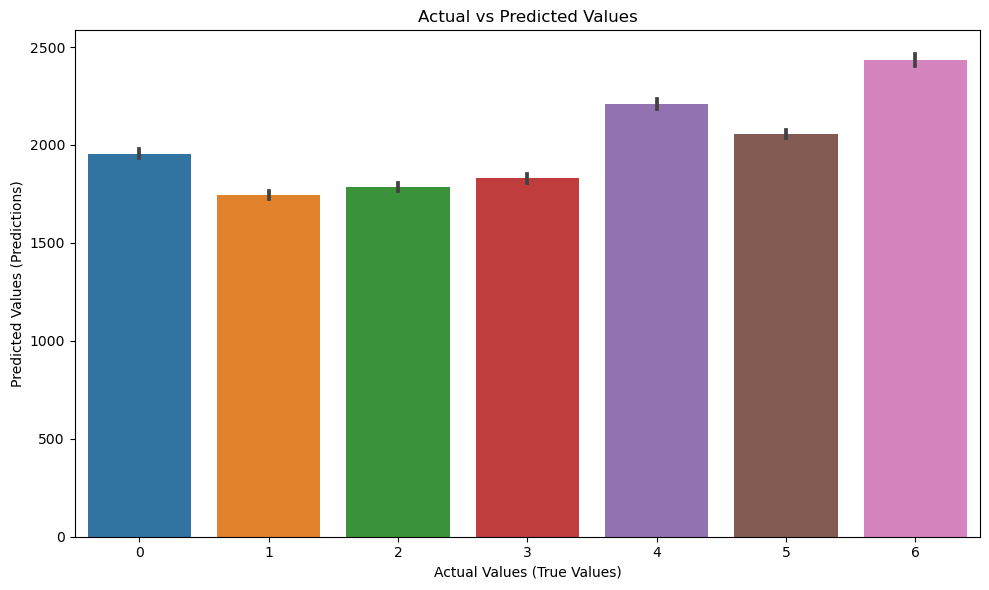

In [3087]:
plt.figure(figsize=(10, 6))
sns.barplot(x='doj_dayofweek', y='final_seatcount', data=df)
plt.xlabel('Actual Values (True Values)')
plt.ylabel('Predicted Values (Predictions)')
plt.title('Actual vs Predicted Values')
plt.tight_layout()
plt.show()

In [3088]:
df.groupby('is_weekend')['final_seatcount'].mean()

is_weekend
0    1873.535687
1    2322.213906
Name: final_seatcount, dtype: float64

In [3089]:
df['south_region']=np.where(
    (df['srcid_region'].isin(['Tamil Nadu','Maharshtra and Goa','Andhra Pradesh','Karnataka'])) |(df['destid_region'].isin(['Tamil Nadu','Maharshtra and Goa','Andhra Pradesh','Karnataka'])),1,0)

In [3090]:
south_region_srcid = df[df['south_region'] == 1]['srcid'].unique()
south_region_srcid

array([45, 46, 47,  9, 48,  5, 35, 44, 28, 43, 18, 42,  2,  3, 34, 26, 15,
       20, 39,  8,  6, 33], dtype=int64)

In [3091]:
south_region_destid = df[df['south_region'] == 1]['destid'].unique()
south_region_destid

array([46, 45, 47,  9, 48,  5, 44, 35, 28, 43, 18, 42, 15, 34,  2,  3, 26,
       20, 39,  6, 30,  8, 33, 10], dtype=int64)

In [3092]:
test['south_region']=np.where(
    (test['srcid'].isin(south_region_srcid)) | (test['destid'].isin(south_region_destid)),1,0)

In [3093]:
df['srcid_tier'].value_counts()

srcid_tier
Tier 1    39648
Tier2     20832
Tier 3     4032
Tier 4     2688
Name: count, dtype: int64

In [3094]:
for i in range(1,5):
  if(i==2):
    df['srcid_tier']=df['srcid_tier'].replace(f"Tier{i}",i)
    df['destid_tier']=df['destid_tier'].replace(f"Tier{i}",i)
  else:
    df['srcid_tier']=df['srcid_tier'].replace(f"Tier {i}",i)
    df['destid_tier']=df['destid_tier'].replace(f"Tier {i}",i)

In [3095]:
# df['focus_city'] = np.where(
#     (df['srcid_tier'] > 2) | (df['destid_tier'] > 2),1,0
# )

In [3096]:
# focus_city_srcid = df[df['focus_city'] == 1]['srcid'].unique()
# focus_city_srcid

In [3097]:
# focus_city_destid = df[df['focus_city'] == 1]['srcid'].unique()
# focus_city_destid

In [3098]:
# test['focus_city']=np.where((
#     (test['srcid'].isin(focus_city_srcid)) | (test['destid'].isin(focus_city_destid))
# ),1,0)

In [3099]:
df=df.sort_values(['route','doj'])
for window in [7,14,28]:
    df[f'rolling_mean_{window}']=df.groupby('route')['final_seatcount'].transform(lambda x:x.rolling(window,min_periods=1).mean())
    df[f'rolling_std_{window}']=df.groupby('route')['final_seatcount'].transform(lambda x:x.rolling(window,min_periods=1).std())


In [3100]:
df=df.sort_values(['route','doj'])
for lag in [1,7,14,21,28]:
    df[f'lag_{lag}']=df.groupby('route')['final_seatcount'].shift(lag)
    df['ewm_alpha_0.3']=df.groupby('route')['final_seatcount'].transform(lambda x:x.ewm(alpha=0.3).mean())


In [3101]:
df['seat_search_ratio']=df['cumsum_seatcount']/(df['cumsum_searchcount']+1)
df['search_ewm']=df.groupby('route')['cumsum_searchcount'].transform(lambda x:x.ewm(alpha=0.2).mean())

In [3102]:
df['rolling_mean_7']

18       1288.000000
118      1416.000000
218      1525.333333
318      1543.000000
418      1454.400000
            ...     
66705    5232.857143
66805    5316.000000
66905    5680.714286
67005    6003.428571
67105    5942.142857
Name: rolling_mean_7, Length: 67200, dtype: float64

# DIkkat

In [3103]:
# df['daily_seatcount']=df.groupby('route_key')['cumsum_seatcount'].diff().fillna(0)

In [3104]:
# df['daily_search_count'] = df.groupby('route_key')['cumsum_searchcount'].diff().fillna(0)

In [3105]:
df.sample(5)

,doj,srcid,destid,final_seatcount,doi,srcid_region,destid_region,srcid_tier,destid_tier,cumsum_seatcount,...,rolling_mean_28,rolling_std_28,lag_1,ewm_alpha_0.3,lag_7,lag_14,lag_21,lag_28,seat_search_ratio,search_ewm
40128,2024-04-05,13,23,1836.0,2024-03-21,East 1,East 1,2,1,24.0,...,2173.000000,805.357340,1216.0,1855.491895,2076.0,2132.0,1760.0,1872.0,0.124352,286.977206
14628,2023-07-25,13,23,1372.0,2023-07-10,East 1,East 1,2,1,0.0,...,1884.000000,519.646604,2292.0,1919.582750,1564.0,1192.0,1464.0,1240.0,0.000000,138.173017
19840,2023-09-15,2,47,2520.0,2023-08-31,Maharashtra and Goa,Andhra Pradesh,1,1,55.0,...,1641.785714,377.200247,1560.0,1787.235620,1800.0,2320.0,1990.0,2055.0,0.016512,1112.768715
50311,2024-07-16,5,47,2118.0,2024-07-01,Andhra Pradesh,Andhra Pradesh,2,1,3.0,...,2710.285714,816.073293,3030.0,2854.481499,2106.0,2478.0,2331.0,2973.0,0.005093,625.020281
37006,2024-03-05,46,48,3456.0,2024-02-19,Tamil Nadu,Tamil Nadu,1,2,30.0,...,4194.750000,1171.600508,2736.0,3396.800054,2538.0,5331.0,3369.0,2571.0,0.010973,2893.451286


In [3106]:
# Route- key used latter in the creation of prediction file

In [3107]:
route_key=test['route_key']

In [3108]:
# Encoding the route_key for both test and df dataframe
all_route_keys = pd.Index(df["route_key"]).union(test["route_key"])
combo_map = {k: i for i, k in enumerate(all_route_keys)}

# Apply the same mapping 
df["route_key"] = df["route_key"].map(combo_map)
test["route_key"] = test["route_key"].map(combo_map)


# Correlation

In [3109]:
df.head()

,doj,srcid,destid,final_seatcount,doi,srcid_region,destid_region,srcid_tier,destid_tier,cumsum_seatcount,...,rolling_mean_28,rolling_std_28,lag_1,ewm_alpha_0.3,lag_7,lag_14,lag_21,lag_28,seat_search_ratio,search_ewm
18,2023-03-01,11,36,1288.0,2023-02-14,Rest of North,Delhi,1,2,4.0,...,1288.000000,NaN,NaN,1288.000000,NaN,NaN,NaN,NaN,0.011594,344.000000
118,2023-03-02,11,36,1544.0,2023-02-15,Rest of North,Delhi,1,2,16.0,...,1416.000000,181.019336,1288.0,1438.588235,NaN,NaN,NaN,NaN,0.116788,228.444444
218,2023-03-03,11,36,1744.0,2023-02-16,Rest of North,Delhi,1,2,8.0,...,1525.333333,228.572381,1544.0,1578.045662,NaN,NaN,NaN,NaN,0.025237,264.327869
318,2023-03-04,11,36,1596.0,2023-02-17,Rest of North,Delhi,1,2,0.0,...,1543.000000,189.943851,1744.0,1585.133833,NaN,NaN,NaN,NaN,0.000000,326.547425
418,2023-03-05,11,36,1100.0,2023-02-18,Rest of North,Delhi,1,2,0.0,...,1454.400000,257.504951,1596.0,1410.191050,NaN,NaN,NaN,NaN,0.000000,290.092337


In [3110]:
from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',
 'inferno_r',
 'plasma_r',
 'viri

In [3111]:
df=df.drop(['srcid_tier','destid_tier','srcid_region','destid_region','doi','dbd'],axis=1)

In [3112]:
df=df.fillna(method='ffill').fillna(0)

C:\Users\vinod\AppData\Local\Temp\ipykernel_8392\450882871.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df=df.fillna(method='ffill').fillna(0)


In [3113]:
df.head()

,doj,srcid,destid,final_seatcount,cumsum_seatcount,cumsum_searchcount,route_key,route,doj_month,doj_week,...,rolling_mean_28,rolling_std_28,lag_1,ewm_alpha_0.3,lag_7,lag_14,lag_21,lag_28,seat_search_ratio,search_ewm
18,2023-03-01,11,36,1288.0,4.0,344.0,0,11_36,3,9,...,1288.000000,0.000000,0.0,1288.000000,0.0,0.0,0.0,0.0,0.011594,344.000000
118,2023-03-02,11,36,1544.0,16.0,136.0,100,11_36,3,9,...,1416.000000,181.019336,1288.0,1438.588235,0.0,0.0,0.0,0.0,0.116788,228.444444
218,2023-03-03,11,36,1744.0,8.0,316.0,200,11_36,3,9,...,1525.333333,228.572381,1544.0,1578.045662,0.0,0.0,0.0,0.0,0.025237,264.327869
318,2023-03-04,11,36,1596.0,0.0,448.0,300,11_36,3,9,...,1543.000000,189.943851,1744.0,1585.133833,0.0,0.0,0.0,0.0,0.000000,326.547425
418,2023-03-05,11,36,1100.0,0.0,204.0,400,11_36,3,9,...,1454.400000,257.504951,1596.0,1410.191050,0.0,0.0,0.0,0.0,0.000000,290.092337


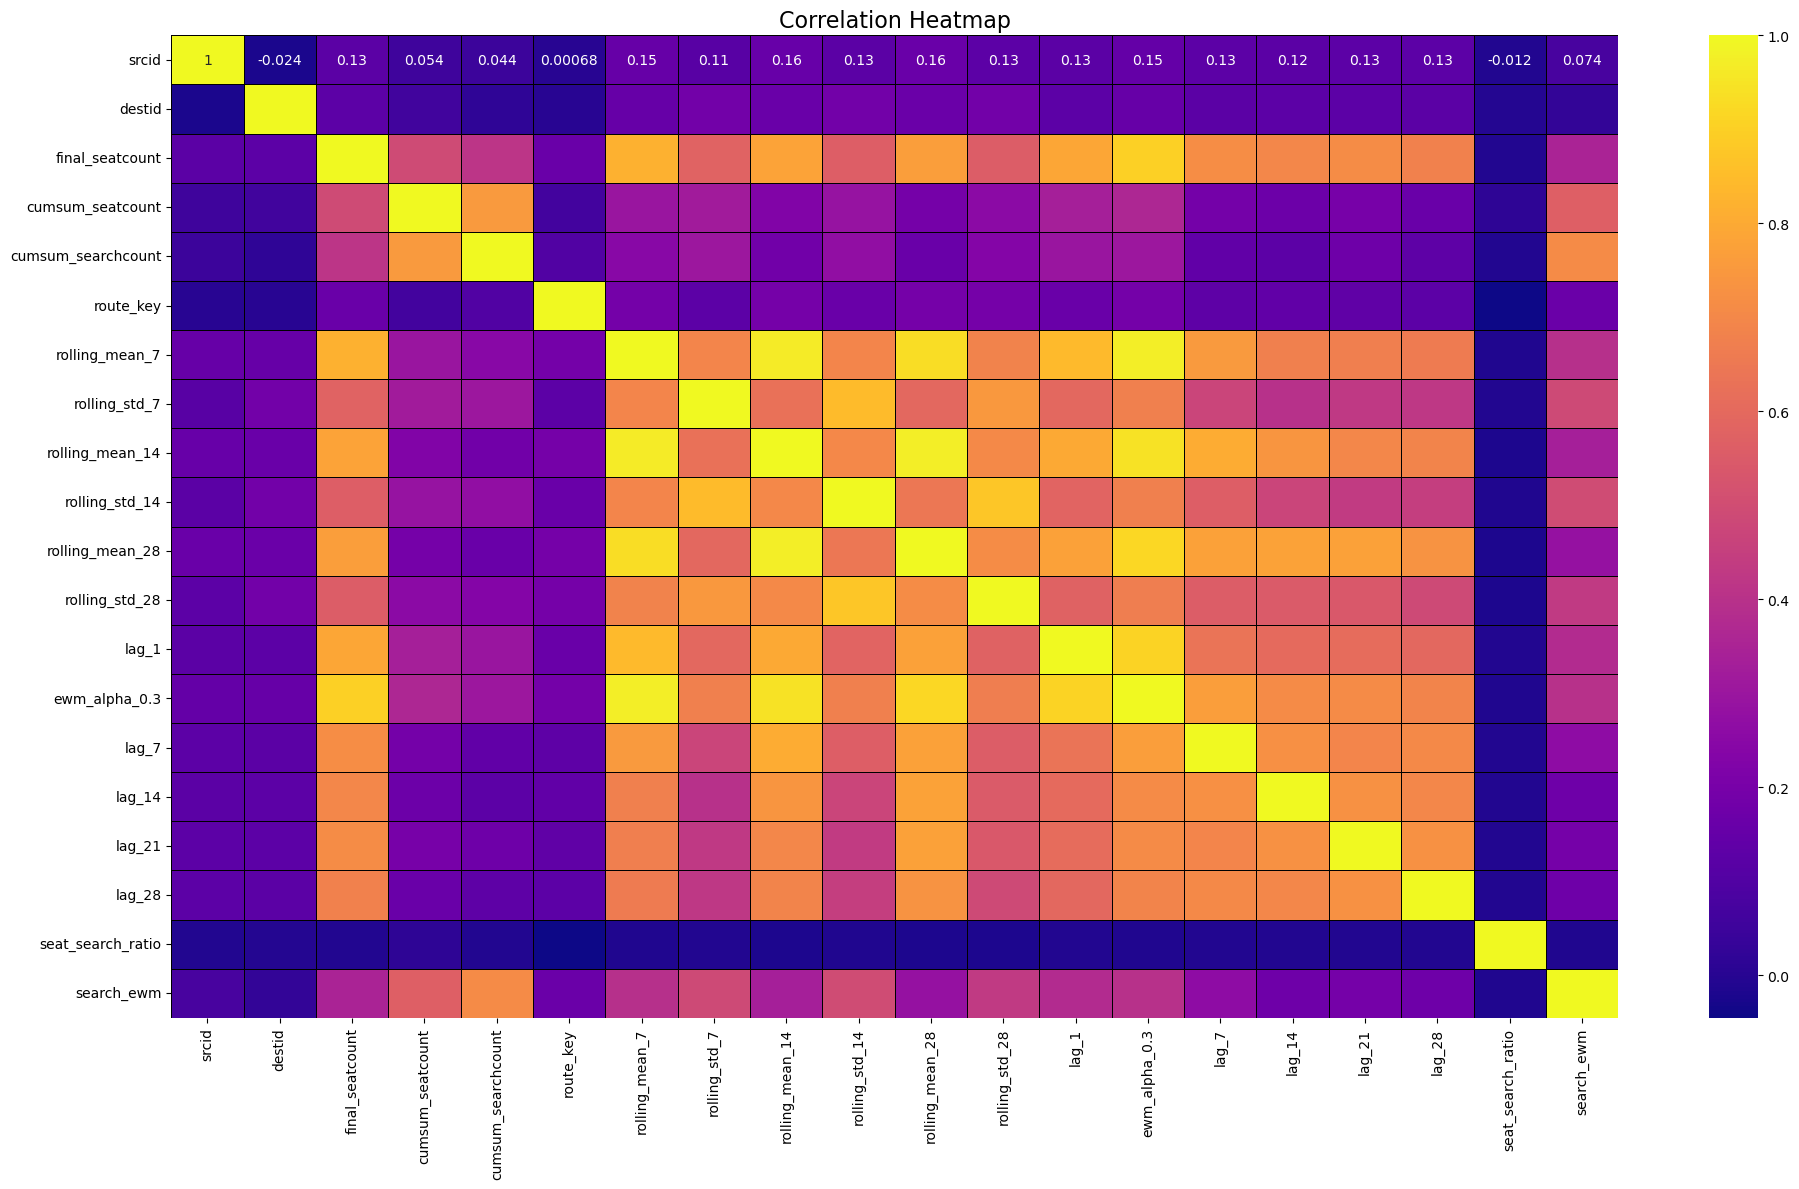

In [3114]:
df1= df.select_dtypes(include=['float64', 'int64']) 
corr = df1.corr()
plt.figure(figsize=(20, 12))
sns.heatmap(corr, annot=True, cmap='plasma', linewidths=0.5, linecolor='black')
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()


In [3115]:
group_cols = [
    'srcid', 'destid','doj']

In [3116]:
seat_agg = df.groupby(group_cols)['cumsum_seatcount'].mean().reset_index()
search_agg = df.groupby(group_cols)['cumsum_searchcount'].mean().reset_index()
# daily_seat_agg = df.groupby(group_cols)['daily_seatcount'].mean().reset_index()
# daily_search_agg = df.groupby(group_cols)['daily_search_count'].mean().reset_index()

In [3117]:
test = test.merge(seat_agg, on=group_cols, how='left')
test = test.merge(search_agg, on=group_cols, how='left')
test = test.merge(daily_seat_agg, on=group_cols, how='left')
test = test.merge(daily_search_agg, on=group_cols, how='left')

In [3118]:
# Optional: Filling any missing values 
test[['cumsum_seatcount', 'cumsum_searchcount', 'daily_seatcount', 'daily_search_count']] = test[['cumsum_seatcount', 'cumsum_searchcount', 'daily_seatcount', 'daily_search_count']].fillna(0)


In [3119]:
test['search_ewm']=test.groupby('route')['cumsum_searchcount'].transform(lambda x:x.ewm(alpha=0.2).mean())
test['seat_search_ratio']=test['cumsum_seatcount']/(test['cumsum_searchcount']+1)

In [3120]:
df1=df

In [3121]:
df2=df1

In [3122]:
df=df2

In [3123]:
test.shape,df.shape

((5900, 17), (67200, 28))

# Model Pipeline for test data

In [3124]:
route_stats=df.groupby('route').agg({
    'final_seatcount':['mean','std'],
    'rolling_mean_7':'last',
    'rolling_mean_14':'last',
    'rolling_mean_28':'last',
    'rolling_std_7':'last',
    'rolling_std_14':'last',
    'rolling_std_28':'last',
    'lag_1':'last',
    'lag_7':'last',
    'lag_14':'last',
    'lag_21':'last',
    'lag_28':'last',
    'ewm_alpha_0.3':'last',
}).reset_index()

In [3125]:
route_stats.columns=['_'.join(col).strip('_') for col in route_stats.columns.values]

In [3126]:
test=test.merge(route_stats,on=['route'],how='left')

In [3127]:
for value in [
     'rolling_mean_7',
    'rolling_mean_14',
    'rolling_mean_28',
    'rolling_std_7',
    'rolling_std_14',
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_21',
    'lag_28',
    'ewm_alpha_0.3',
]:
    if value not in test.columns:
        if 'rolling_mean' in value:
            test[value]=test['final_seatcount_mean']
        elif 'rolling_std' in value:
            test[value]=test['final_seatcount_std']
        if 'lag_' in value:
            test[value]=test['final_seatcount_mean']
        if 'ewm' in value:
            test[value]=test['final_seatcount_std']

In [3128]:
test=test.fillna(0)

In [3129]:
df.columns

Index(['doj', 'srcid', 'destid', 'final_seatcount', 'cumsum_seatcount',
       'cumsum_searchcount', 'route_key', 'route', 'doj_month', 'doj_week',
       'doj_day', 'doj_dayofweek', 'is_weekend', 'south_region',
       'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14',
       'rolling_mean_28', 'rolling_std_28', 'lag_1', 'ewm_alpha_0.3', 'lag_7',
       'lag_14', 'lag_21', 'lag_28', 'seat_search_ratio', 'search_ewm'],
      dtype='object')

In [3130]:
test.columns

Index(['route_key', 'doj', 'srcid', 'destid', 'route', 'doj_month', 'doj_week',
       'doj_day', 'doj_dayofweek', 'is_weekend', 'south_region',
       'cumsum_seatcount', 'cumsum_searchcount', 'daily_seatcount',
       'daily_search_count', 'search_ewm', 'seat_search_ratio',
       'final_seatcount_mean', 'final_seatcount_std', 'rolling_mean_7_last',
       'rolling_mean_14_last', 'rolling_mean_28_last', 'rolling_std_7_last',
       'rolling_std_14_last', 'rolling_std_28_last', 'lag_1_last',
       'lag_7_last', 'lag_14_last', 'lag_21_last', 'lag_28_last',
       'ewm_alpha_0.3_last', 'rolling_mean_7', 'rolling_mean_14',
       'rolling_mean_28', 'rolling_std_7', 'rolling_std_14', 'lag_1', 'lag_7',
       'lag_14', 'lag_21', 'lag_28', 'ewm_alpha_0.3'],
      dtype='object')

In [3131]:
# test = test[[col for col in df.columns if col in test.columns]]
test=test.drop(['doj','route','rolling_std_28_last','daily_search_count','daily_seatcount','srcid','destid'],axis=1)
df=df.drop(['doj','route','rolling_std_28','srcid','destid'],axis=1)

In [3132]:
df_cols = set(df.columns)
test_cols = set(test.columns)
non_common_columns = df_cols.symmetric_difference(test_cols)
print(list(non_common_columns))


['lag_1_last', 'lag_28_last', 'lag_7_last', 'rolling_mean_7_last', 'final_seatcount_std', 'ewm_alpha_0.3_last', 'rolling_mean_14_last', 'final_seatcount', 'final_seatcount_mean', 'rolling_std_7_last', 'rolling_mean_28_last', 'lag_14_last', 'lag_21_last', 'rolling_std_14_last']


In [3133]:
test=test.drop(['lag_1_last','lag_28_last', 'lag_7_last', 'rolling_mean_7_last', 'final_seatcount_std', 'ewm_alpha_0.3_last', 'rolling_mean_14_last', 'final_seatcount_mean', 'rolling_std_7_last', 'rolling_mean_28_last', 'lag_14_last', 'lag_21_last', 'rolling_std_14_last'],axis=1)

In [3134]:
test.columns

Index(['route_key', 'doj_month', 'doj_week', 'doj_day', 'doj_dayofweek',
       'is_weekend', 'south_region', 'cumsum_seatcount', 'cumsum_searchcount',
       'search_ewm', 'seat_search_ratio', 'rolling_mean_7', 'rolling_mean_14',
       'rolling_mean_28', 'rolling_std_7', 'rolling_std_14', 'lag_1', 'lag_7',
       'lag_14', 'lag_21', 'lag_28', 'ewm_alpha_0.3'],
      dtype='object')

In [3135]:
df.columns

Index(['final_seatcount', 'cumsum_seatcount', 'cumsum_searchcount',
       'route_key', 'doj_month', 'doj_week', 'doj_day', 'doj_dayofweek',
       'is_weekend', 'south_region', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28', 'lag_1',
       'ewm_alpha_0.3', 'lag_7', 'lag_14', 'lag_21', 'lag_28',
       'seat_search_ratio', 'search_ewm'],
      dtype='object')

In [3136]:
x=df[test.columns]

In [3137]:
x=df.drop(['final_seatcount'],axis=1)
y=df['final_seatcount']
x.shape,y.shape

((67200, 22), (67200,))

In [3138]:
columns=x.columns
x.iloc[0,:]

cumsum_seatcount         4.000000
cumsum_searchcount     344.000000
route_key                0.000000
doj_month                3.000000
doj_week                 9.000000
doj_day                  1.000000
doj_dayofweek            2.000000
is_weekend               0.000000
south_region             0.000000
rolling_mean_7        1288.000000
rolling_std_7            0.000000
rolling_mean_14       1288.000000
rolling_std_14           0.000000
rolling_mean_28       1288.000000
lag_1                    0.000000
ewm_alpha_0.3         1288.000000
lag_7                    0.000000
lag_14                   0.000000
lag_21                   0.000000
lag_28                   0.000000
seat_search_ratio        0.011594
search_ewm             344.000000
Name: 18, dtype: float64

# Finalizing Test Data 

In [3139]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [3140]:
x_scaled=scaler.fit_transform(x)
x_scaled

array([[8.46740051e-04, 8.78752580e-04, 0.00000000e+00, ...,
        0.00000000e+00, 1.36402387e-04, 2.31015486e-03],
       [3.38696020e-03, 3.47413811e-04, 1.48811738e-03, ...,
        0.00000000e+00, 1.37398025e-03, 1.53413385e-03],
       [1.69348010e-03, 8.07226207e-04, 2.97623477e-03, ...,
        0.00000000e+00, 2.96901095e-04, 1.77511137e-03],
       ...,
       [9.97036410e-02, 2.62552878e-02, 9.97023765e-01, ...,
        5.69429016e-01, 5.39077388e-04, 3.68868292e-02],
       [7.30313294e-02, 1.72812826e-02, 9.98511883e-01, ...,
        4.22350589e-01, 5.99885239e-04, 3.85956248e-02],
       [4.31837426e-02, 1.37560542e-02, 1.00000000e+00, ...,
        3.61475228e-01, 4.45599703e-04, 3.81091649e-02]])

In [3141]:
test=scaler.fit_transform(test)

In [3142]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,random_state=42,test_size=0.1)

In [3143]:
x_train

array([[0.00000000e+00, 2.47787791e-03, 4.29887350e-01, ...,
        9.44234615e-02, 0.00000000e+00, 2.86787896e-03],
       [1.16426757e-02, 1.04224143e-02, 4.83533981e-01, ...,
        1.32933422e-01, 1.58553988e-04, 3.79548554e-02],
       [3.17527519e-03, 1.06012303e-03, 2.72518936e-01, ...,
        6.22083981e-02, 4.24208145e-04, 2.40941524e-03],
       ...,
       [0.00000000e+00, 3.29532218e-03, 6.76810667e-01, ...,
        1.57002148e-01, 0.00000000e+00, 1.24995999e-02],
       [5.08044030e-03, 4.70030450e-04, 2.79780949e-01, ...,
        6.54669333e-02, 1.52623211e-03, 4.69856855e-03],
       [4.23370025e-03, 1.49439029e-03, 5.04814060e-01, ...,
        1.29971118e-01, 4.01525798e-04, 7.25928535e-03]])

# Training The model

In [3193]:
def train_model(X_train, y_train, X_val, y_val):
    model = LGBMRegressor(
        learning_rate=0.05,
        max_depth=24,
        num_leaves=74,
        feature_fraction=0.8,
        bagging_fraction=0.75,
        bagging_freq=8,
        n_estimators=1000,
        random_state=42,
        force_col_wise=True 
    )
    
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            early_stopping(stopping_rounds=100),
            log_evaluation(period=100)
        ]
    )
    
    return model

# Evaluating and plotting 

In [3194]:
def evaluate_model(model, X_val, y_val):
    val_preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    mae = mean_absolute_error(y_val, val_preds)
    r2 = r2_score(y_val, val_preds)
    
    print(f"\nValidation Metrics:")
    print(f"RMSE: {rmse:.4f}")
    
    plt.figure(figsize=(10, 8))
    feat_imp = pd.Series(model.feature_importances_, index=columns)
    feat_imp.nlargest(22).sort_values().plot(kind='barh')
    plt.title('Top Feature Importances')
    plt.tight_layout()
    plt.savefig('Most_Important_features.png')
    plt.show()
    
    plt.figure(figsize=(10, 6))
    sns.regplot(x=y_val, y=val_preds, scatter_kws={'alpha':0.3})
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--')
    plt.xlabel('Actual Values (True Values)')
    plt.ylabel('Predicted Values (Predictions)')
    plt.title('Actual vs Predicted Values')
    plt.tight_layout()
    plt.savefig('Actual_Vs_Predicted.png')
    plt.show()
    
    # Plot error distribution
    errors = y_val - val_preds
    plt.figure(figsize=(10, 6))
    sns.histplot(errors, kde=True)
    plt.xlabel('Prediction Error')
    plt.title('Error Distribution')
    plt.tight_layout()
    plt.savefig('REDBUS_error.png')
    plt.show()

In [3195]:
model=train_model(x_train,y_train,x_test,y_test)

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.75, subsample=1.0 will be ignored. Current value: bagging_fraction=0.75
[LightGBM] [Warning] bagging_freq is set=8, subsample_freq=0 will be ignored. Current value: bagging_freq=8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.75, subsample=1.0 will be ignored. Current value: bagging_fraction=0.75
[LightGBM] [Warning] bagging_freq is set=8, subsample_freq=0 will be ignored. Current value: bagging_freq=8
[LightGBM] [Info] Total Bins 4186
[LightGBM] [Info] Number of data points in the train set: 60480, number of used features: 22
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.75, subsample=1.0 will be ignored. Current value: bagging_fraction=0.75
[LightGBM] [Warning] bagging_freq is set=8, subsample_freq=0 will be ignored. Current value: bagging_freq=8

Validation Metrics:
RMSE: 185.1577


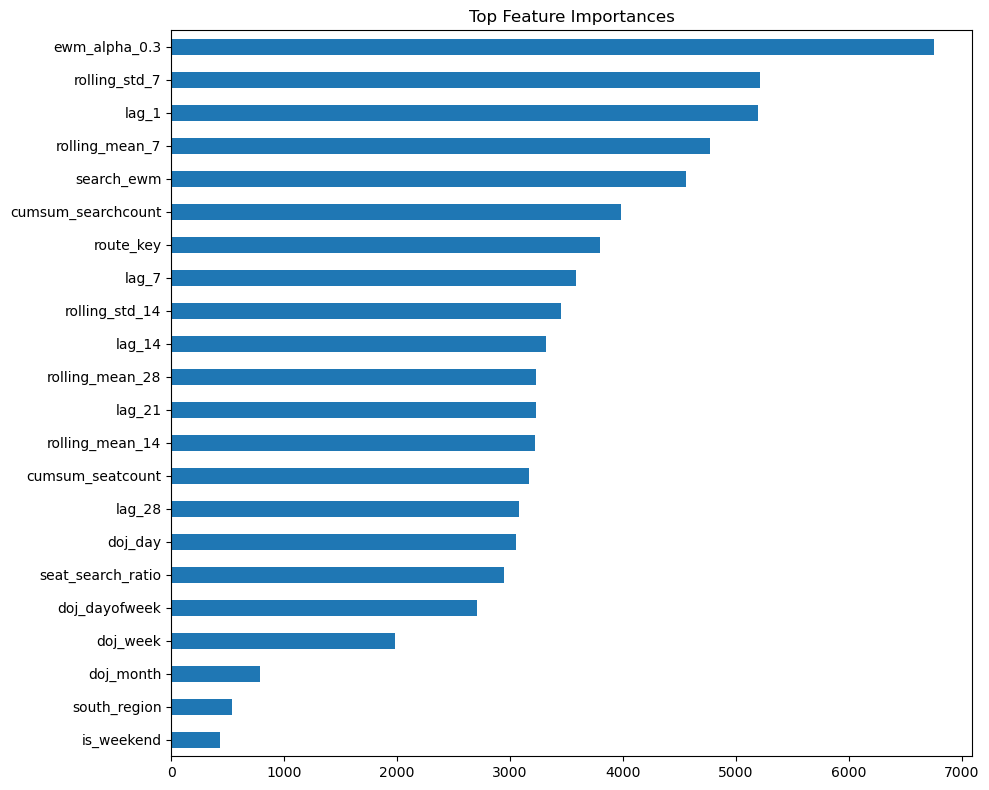

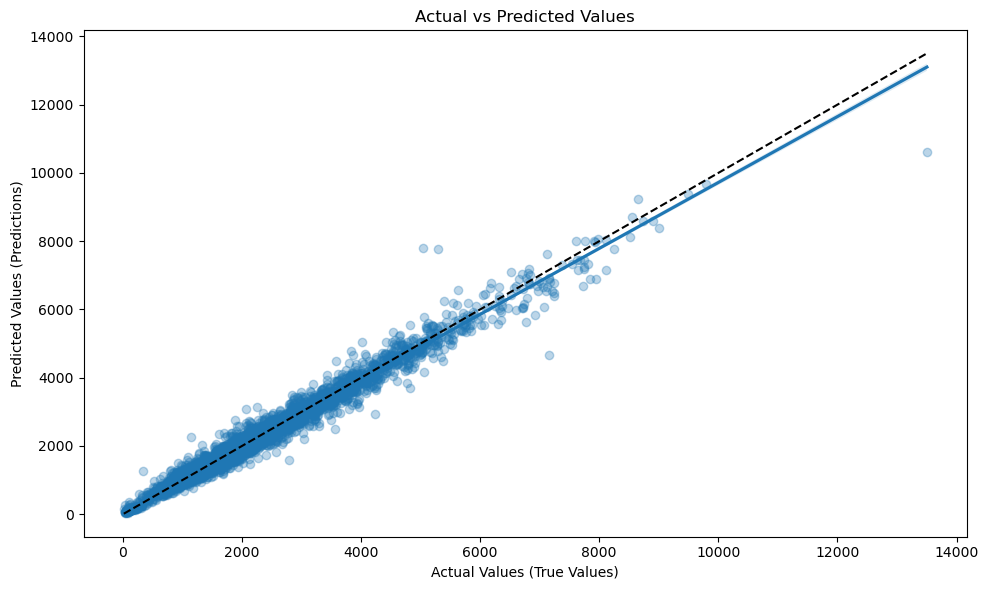

C:\Users\vinod\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


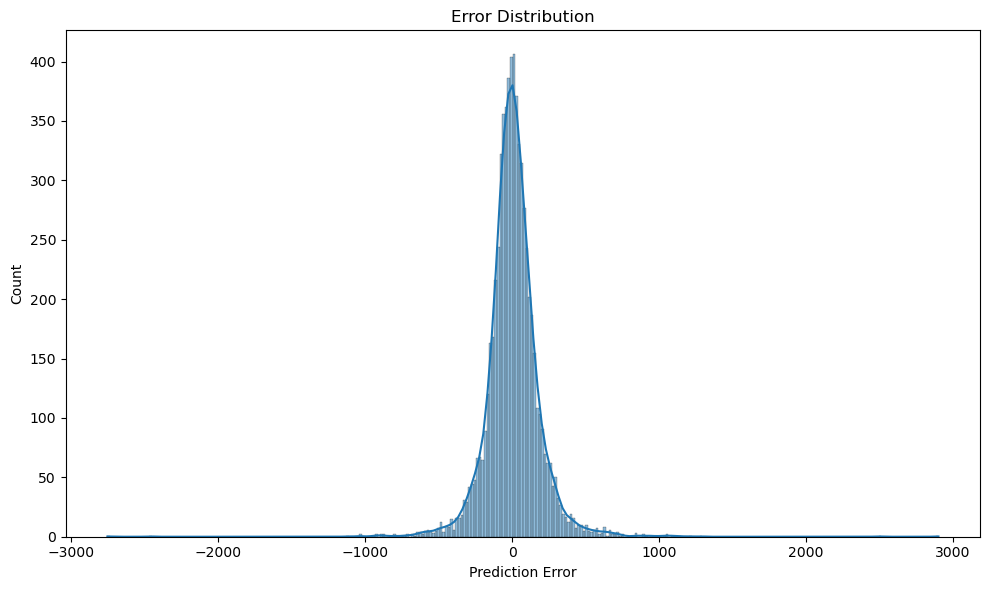

In [3196]:
evaluate_model(model,x_test,y_test)

# Predicting Test

In [3197]:
y_pred=model.predict(test)

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.75, subsample=1.0 will be ignored. Current value: bagging_fraction=0.75
[LightGBM] [Warning] bagging_freq is set=8, subsample_freq=0 will be ignored. Current value: bagging_freq=8


In [3198]:
output_df = pd.DataFrame({
    'route_key': route_key,
    'final_seatcount': y_pred
})

# Save to CSV
output_df.to_csv('predictions1.csv', index=False)